<a href="https://colab.research.google.com/github/sakram09/Explainable-AI-XAI-in-Ecological-Modeling/blob/main/XAI_ECOLOGY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Explainable AI (XAI) in Ecological Modeling

Model trained! Now introducing Explainable AI (XAI)...

Generating Global SHAP Summary Plot...


/tmp/ipykernel_31099/1390199386.py:43: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test, show=False)


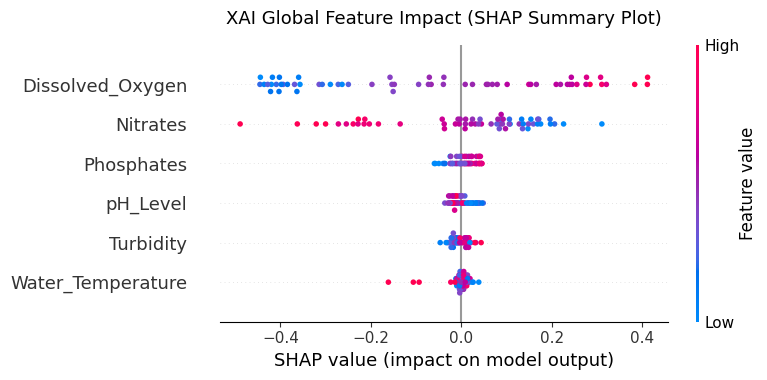


Generating Local Explanation Plot for Site #0...


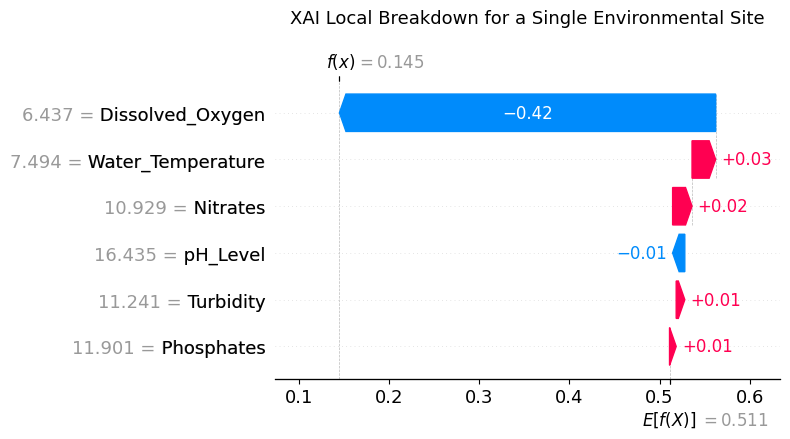

In [1]:
# 1. Install and Import SHAP and core libraries
!pip install shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 2. Simulate the Ecology Dataset (Same as Project 3 for consistency)
np.random.seed(42)
num_sites = 300 # Kept small for fast SHAP calculation

feature_names = ['Water_Temperature', 'pH_Level', 'Dissolved_Oxygen', 'Nitrates', 'Phosphates', 'Turbidity']
X_data = np.random.normal(loc=10, scale=3, size=(num_sites, len(feature_names)))
df_eco = pd.DataFrame(X_data, columns=feature_names)

# Injected ecological rule
biodiversity_score = (df_eco['Dissolved_Oxygen'] * 3.0) - (df_eco['Nitrates'] * 1.5)
y_eco = (biodiversity_score > np.median(biodiversity_score)).astype(int)

# 3. Train a quick Random Forest Model (The Black Box)
X_train, X_test, y_train, y_test = train_test_split(df_eco, y_eco, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("Model trained! Now introducing Explainable AI (XAI)...")

# ========================================================
# XAI IMPLEMENTATION WITH SHAP
# ========================================================

# 4. Initialize SHAP TreeExplainer for our Random Forest Model
explainer = shap.TreeExplainer(model)

# 5. Calculate SHAP values for the test dataset (For class 1: Healthy)
shap_values = explainer(X_test)

# Plot 1: Global Summary Plot (Poore model ka macro view)
print("\nGenerating Global SHAP Summary Plot...")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title("XAI Global Feature Impact (SHAP Summary Plot)", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Plot 2: Local Explanation Plot (Kisi ek single site ka post-mortem)
print("\nGenerating Local Explanation Plot for Site #0...")
plt.figure(figsize=(10, 4))
# Explaining the prediction for the very first sample in the test set
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.title("XAI Local Breakdown for a Single Environmental Site", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

"Professors usually don't trust standard Machine Learning because it acts as a black box. In this project, I integrated Explainable AI using SHAP. As you can see in this waterfall plot, for this specific degraded site, the model didn't just guess blindly—it shows that the low Dissolved Oxygen level pushed the model's prediction threshold down by 30%, giving us direct biological justification behind the algorithm's decision."

In [2]:
import joblib
import pickle

# 1. Save the trained Black-Box Random Forest Model (using joblib)
joblib.dump(model, 'ecology_xai_rf_model.pkl')

# 2. Save the SHAP Explainer (SHAP explainer ko save karne ke liye standard pickle best hai)
with open('shap_tree_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("Success! Dono XAI components save ho chuke hain.")
print("Files: ecology_xai_rf_model.pkl, shap_tree_explainer.pkl")

Success! Dono XAI components save ho chuke hain.
Files: ecology_xai_rf_model.pkl, shap_tree_explainer.pkl


In [3]:
import joblib
import pickle
import shap

# 1. Dono saved components ko load karein
loaded_model = joblib.load('ecology_xai_rf_model.pkl')

with open('shap_tree_explainer.pkl', 'rb') as f:
    loaded_explainer = pickle.load(f)

print("XAI Pipeline Loaded Successfully!")

# Farz karein aapke paas koi naya site observation data aaya hai (e.g., New_Site_Data)
# Aap bina training ke direct uska SHAP waterfall plot nikal sakti hain:
# new_shap_values = loaded_explainer(New_Site_Data)
# shap.plots.waterfall(new_shap_values[0, :, 1])

XAI Pipeline Loaded Successfully!
